# 学习张量（Tensor）是什么，与 NumPy 数组的区别
## 掌握：
    torch.tensor(), torch.zeros(), torch.ones(), torch.randn()
    .dtype, .device, .shape
    张量在 CPU/GPU 上的移动（.to(device)）
    创建不同类型的张量并转换设备（如有 GPU）
    用 PyTorch 创建一个 3×3 的随机张量，并将其移到 GPU（如果可用）



In [183]:
import numpy as np
import torch
from numpy.ma.core import argmin

# 正确的设备选择
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available()
    else "cpu"
)


test1_np = np.random.randn(100) * 10
test1_np = test1_np.reshape((10,10))
# np转tensor
test1_tensor = torch.tensor(test1_np)
# 生成大小为5 * 5 的tensor全0矩阵
test2_tensor = torch.zeros((5,5))
# 生成大小为3 * 3 的tensor全1矩阵
test3_tensor = torch.ones((3,3))
# 生成长度为25的向量
test4_tensor = torch.randn((5 * 5))
# 转成为5 * 5 的矩阵
test5_tensor = test4_tensor.reshape((5,5))
# 转到gpu再转回cpu
test5_tensor.to(device).cpu()

tensor([[ 1.7311,  0.7689,  0.4440, -1.2591,  1.3768],
        [-0.3493,  0.9732,  0.2928,  0.0103, -0.9402],
        [-1.3513, -0.2107, -0.9602,  0.3227,  0.2637],
        [-0.6631,  0.7361, -0.6810,  0.1698, -0.4936],
        [-0.6167,  0.4300, -0.8738,  0.2140, -0.2926]])

# 基本运算：加减乘除、点积（torch.mm, @）、转置（.T）
## 索引与切片（类似 NumPy）
    形状变换：view(), reshape(), unsqueeze(), squeeze()
    广播机制（Broadcasting）
    与 NumPy 互转：.numpy(), torch.from_numpy(),使用torch.from_numpy更加安全，使用tensor.Tensor在非float类型下会与预期不符。
    实现两个矩阵相乘，并 reshape 成 (9,) 向量
    torch.tensor 适用于从任何类型的数据创建独立的张量，并不与原始数据共享内存，适合需要深拷贝和数据隔离的场景。
    torch.from_numpy 适合从 NumPy 数组快速创建张量，且共享内存，适合在需要高效数据传递和共享内存的场景下使用。

In [184]:
import torch

# 生成长度为25的向量
test5_tensor = torch.randn((5 * 5))

test5_tensor = test5_tensor.view((5,5))

tes6_tensor = test5_tensor.reshape((5*5))


# 生成一个0-10的tensor
test7_tensor = torch.arange(0,9)

test8_tensor = test7_tensor.view((3,3))
# 扩展维度
test9_tensor = test8_tensor.unsqueeze(2)
# 降维,把维度为1的降下来
test10_tensor = test9_tensor.squeeze(2)

# 可广播，会像高维补齐
c = torch.empty(5, 1, 4, 1)
d = torch.empty(   3, 1, 1)
(c + d).size()

(c * d).reshape(-1)

test2_np = (np.random.randn(4) * 10).reshape((2,2))
test12_tensor = torch.from_numpy(test2_np)
test13_tensor = torch.tensor(test2_np)
test2_np,test12_tensor,test13_tensor

(array([[ -9.85131802,  -8.83677166],
        [-10.33946517, -22.17263243]]),
 tensor([[ -9.8513,  -8.8368],
         [-10.3395, -22.1726]], dtype=torch.float64),
 tensor([[ -9.8513,  -8.8368],
         [-10.3395, -22.1726]], dtype=torch.float64))

## 自动求导（Autograd）原理与实践
## 理解计算图（Computation Graph）
    requires_grad=True
    .backward() 和 .grad
    阻断梯度：.detach(), with torch.no_grad():
    梯度清零：.zero_grad()
    定义 y = x² + 2x + 1，手动计算 dy/dx 在 x=3 处的值，并用 Autograd 验证

In [185]:
import torch

def f(x):
    return x ** 2 + 2 * x +1

def f_grad(x):
    return 2 * x +2


test_x = torch.tensor(1.0,requires_grad=True)
y = f(test_x)
y.backward()

print(f'手动计算梯度：{f_grad(test_x.item())},自动计算梯度：{test_x.grad}')

手动计算梯度：4.0,自动计算梯度：4.0


# 目标：学会准备和加载数据

## 学习内容：
    torch.utils.data.Dataset
    torch.utils.data.DataLoader
    批处理、打乱、多进程加载
    动手练习：
    创建一个自定义 Dataset（如生成 y = 2x + 1 + noise 的合成数据）
    用 DataLoader 加载并遍历


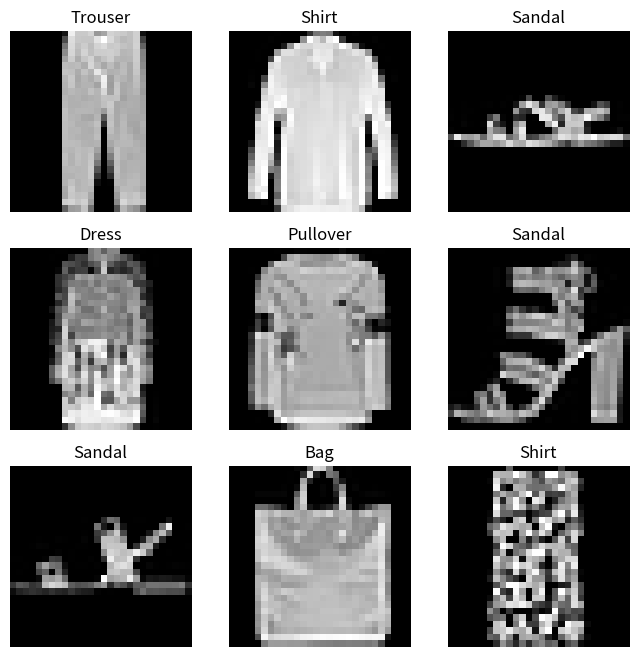

In [186]:
# pytorch 自带数据集使用
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt


training_data = datasets.FashionMNIST(
    root="../../data/fashion-MNIST",        # 存储位置
    train=True,     # 是否用于训练，里面需要自己写函数处理，根据不同传参进行选择数据集
    download=True,  # 是否下载
    transform=ToTensor()    # 参数指定对图像数据进行的预处理操作，是一个转换函数，它将 PIL 图像或 NumPy 数组（像素值范围通常是 0–255）转换为 PyTorch 的 FloatTensor，并将像素值归一化到 [0.0, 1.0] 范围
)

test_data = datasets.FashionMNIST(
    root="../../data/fashion-MNIST",
    train=False,
    download=False,
    transform=ToTensor()
)

labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

### 自定义dataset
    必须实现三个函数：__init__、__len__ 和 __getitem__

In [187]:
import os
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):
    """
    __init__作用
    加载或准备数据（如读取文件路径、加载整个数据集到内存、读取标签等）
    保存配置参数（如是否训练、数据增强方式、归一化参数等）
    初始化转换操作（transforms）
    建立索引映射（如样本 ID 到文件名的映射）
    """
    def __init__(self,
                 annotations_file,
                 img_dir,
                 transform=None,
                 target_transform=None      # transform（处理输入数据），但专门用于处理标签（label/target），需要自己写函数当参数传入
                 ):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform
    """
    __len__
    函数返回数据集中的样本数量
    """
    def __len__(self):
        return len(self.img_labels)
    """
    __getitem__
    函数从给定索引 idx 的数据集中加载并返回一个样本。根据索引，它识别图像在磁盘上的位置，使用 decode_image 将其转换为张量，从 self.img_labels 中的 csv 数据检索相应的标签，对其调用转换函数（如果适用），并在元组中返回张量图像和相应的标签。
    """
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

### DataLoader的迭代
    我们已将该数据集加载到 DataLoader 中，并可根据需要遍历该数据集。
    以下每次迭代都会返回一批 train_features 和 train_labels（分别包含 batch_size=64 个特征和标签）。
    由于我们指定了 shuffle=True，因此在遍历所有批次后，数据将被打乱顺序。

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


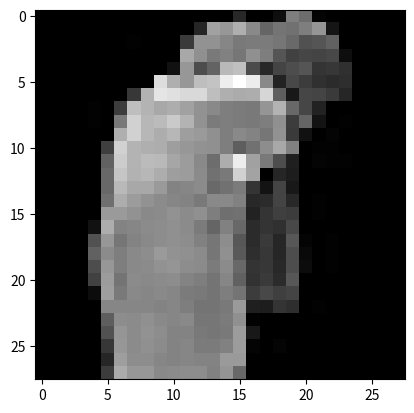

Label: 0


In [188]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

    创建一个自定义 Dataset（如生成 y = 2x + 1 + noise 的合成数据）
    用 DataLoader 加载并遍历

In [189]:
from torch.utils.data import Dataset, DataLoader
import numpy as np

# 定义目标函数
def true_func(x):
    return 2 * x + 1

class LinearLabelDataSet(Dataset):
    def __init__(self, func, num_samples=100, x_range=(-5, 5), noise_std=1.0):
        self.num_samples = num_samples
        # 生成 x 值
        x = np.linspace(x_range[0], x_range[1], num_samples)
        # 生成噪声
        noise = np.random.normal(loc=0.0, scale=noise_std, size=x.shape)
        # 计算带噪声的 y
        y = func(x) + noise

        # 转换为 PyTorch 张量，增加一个维度以适配 MLP 输入
        self.x = torch.tensor(x, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

dataset = LinearLabelDataSet(true_func, num_samples=100, noise_std=0.5)
dataloader = DataLoader(dataset, batch_size=10, shuffle=True)
train_features, train_labels = next(iter(dataloader))
train_features,train_labels

(tensor([[-1.6667],
         [-3.5859],
         [-0.6566],
         [ 3.8889],
         [ 3.3838],
         [ 3.7879],
         [ 2.0707],
         [-1.4646],
         [ 4.0909],
         [ 1.7677]]),
 tensor([[-2.6405],
         [-5.7456],
         [-0.4282],
         [ 8.4710],
         [ 8.3571],
         [ 8.9121],
         [ 5.2424],
         [-1.7433],
         [10.1758],
         [ 4.4456]]))

### 用 PyTorch 实现线性回归（从零开始）
### 目标：完整实现一个线性回归模型

    学习内容：
    定义模型参数（torch.randn(..., requires_grad=True)）
    定义损失函数（MSE）
    手动实现梯度下降更新
    训练循环结构
    动手练习：
    在第 4 天的数据上训练模型
    绘制 loss 曲线和拟合结果
    今日小项目：保存训练好的权重，并用新数据做预测

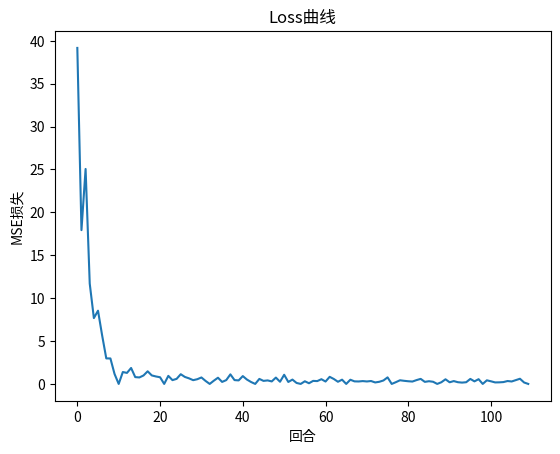

预测均方误差：0.0611889474093914


In [190]:
import matplotlib as mpl
mpl.rcParams.update({
    'font.sans-serif': ['Noto Sans CJK JP'],  # 或 WenQuanYi Zen Hei + 避免 \u2212
    'axes.unicode_minus': False,
    'mathtext.fontset': 'stix'
})
import torch
import matplotlib.pyplot as plt
# 初始化权重的偏置
params = torch.tensor([0.0, 0.0], requires_grad=True)

# 定义损失函数
def loss_mse(pred_y, true_y):
    return ((pred_y - true_y) ** 2).mean()

#定义模型
def model(x):
    ones = torch.ones_like(x)
    x_aug = torch.cat([x, ones], dim=1)
    return x_aug @ params.unsqueeze(1)

# 定义学习率
lr = 0.01

losses = []
for epoch in range(10):
    total_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        pre_y = model(X)
        loss = loss_mse(pre_y,y)
        losses.append(loss.detach().numpy())
        # 反向传播
        loss.backward()  # 对标量损失调用 backward()

        # 手动更新参数
        with torch.no_grad():
            params -= lr * params.grad
            params.grad.zero_()

    avg_loss = total_loss / len(dataloader)
    losses.append(avg_loss)
# 绘图
plt.plot(losses)
plt.title("Loss曲线")
plt.xlabel("回合")
plt.ylabel("MSE损失")
plt.show()

# --- 保存模型 ---
torch.save({'params':params}, '../../data/pytorch_learn/linear_model.pth')

# 加载模型进行新参数预测
dataset_test = LinearLabelDataSet(true_func, num_samples=10, noise_std=0.5)
dataloader_test = DataLoader(dataset_test, batch_size=10, shuffle=True)

torch.load("../../data/pytorch_learn/linear_model.pth", weights_only=True)

for batch, (X, y) in enumerate(dataloader_test):
    ones = torch.ones_like(X)
    x_aug = torch.cat([X, ones], dim=1)
    pre_y = x_aug @ params.unsqueeze(1)
    print(f'预测均方误差：{loss_mse(pre_y,y)}')

### 使用 nn.Module 和内置优化器重构线性回归
### 目标：掌握 PyTorch 的高层 API
    学习内容：
    torch.nn.Linear
    torch.nn.MSELoss
    torch.optim.SGD / Adam
    自定义 nn.Module 类
    动手练习：
    用 nn.Module 重写线性回归模型
    使用优化器替代手动更新
    对比两种实现的效果与代码简洁性
    今日小项目：尝试不同学习率，观察收敛速度

In [194]:
import torch
from torch import nn

# 正确的设备选择
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available()
    else "cpu"
)

model = nn.Linear(in_features = 1, out_features = 1).to(device)
print(model)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

losses = []
for epoch in range(10):
    total_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)  # 移到设备
        pre_y = model(X)
        loss_mse = loss_fn(pre_y, y)
        loss_mse.backward()

        optimizer.step()
        optimizer.zero_grad()
    avg_loss = total_loss / len(dataloader)
    losses.append(avg_loss)

model.state_dict()

Linear(in_features=1, out_features=1, bias=True)


OrderedDict([('weight', tensor([[2.0259]], device='cuda:0')),
             ('bias', tensor([0.8992], device='cuda:0'))])